Track how often recalls pull in items that were not studied in the current list.

Adjust `trial_query` to focus on different conditions or list lengths.


In [1]:
import matplotlib.pyplot as plt
import os

from jaxcmr.analyses.intrusion_error_rate import plot_intrusion_error_rate
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/Gordon2021.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "jnp.logical_and(data['condition'] == 2, data['listLength'] == 7)"


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)


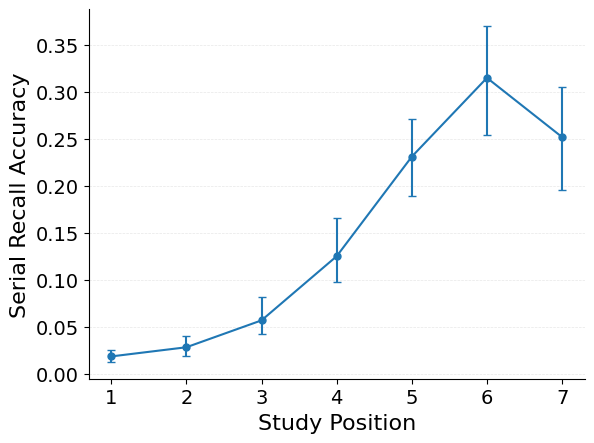

In [4]:
plot_intrusion_error_rate(
    datasets=data,
    trial_masks=trial_mask,
);
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)
